In [1]:
import pandas as pd 


In [4]:
df = pd.read_csv("clean_output.csv")

In [5]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_0,cp_1,...,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3,target
0,-0.267966,1,-0.376556,0.196347,0,0.806035,0,0.161290,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.157260,1,0.478910,0.175799,1,0.237495,1,0.500000,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,1.724733,1,0.764066,0.109589,0,-1.074521,1,0.419355,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.728383,1,0.935159,0.175799,0,0.499898,0,0.000000,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,0.839089,0,0.364848,0.383562,1,-1.905464,0,0.306452,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


In [6]:
df.isnull().sum()

age          0
sex          0
trestbps     0
chol         0
fbs          0
thalach      0
exang        0
oldpeak      0
cp_0         0
cp_1         0
cp_2         0
cp_3         0
restecg_0    0
restecg_1    0
restecg_2    0
slope_0      0
slope_1      0
slope_2      0
ca_0         0
ca_1         0
ca_2         0
ca_3         0
ca_4         0
thal_0       0
thal_1       0
thal_2       0
thal_3       0
target       0
dtype: int64

In [13]:
def plot_kde(df):
   numeric_cols = df.select_dtypes(include='number')
   plt.figure(figsize=(20,40))
   
   for i, col in enumerate(numeric_cols):
      plt.subplot(11,4, i+ 1)
      sns.kdeplot(df[col])

In [17]:
import matplotlib.pyplot as plt 
import seaborn as sns

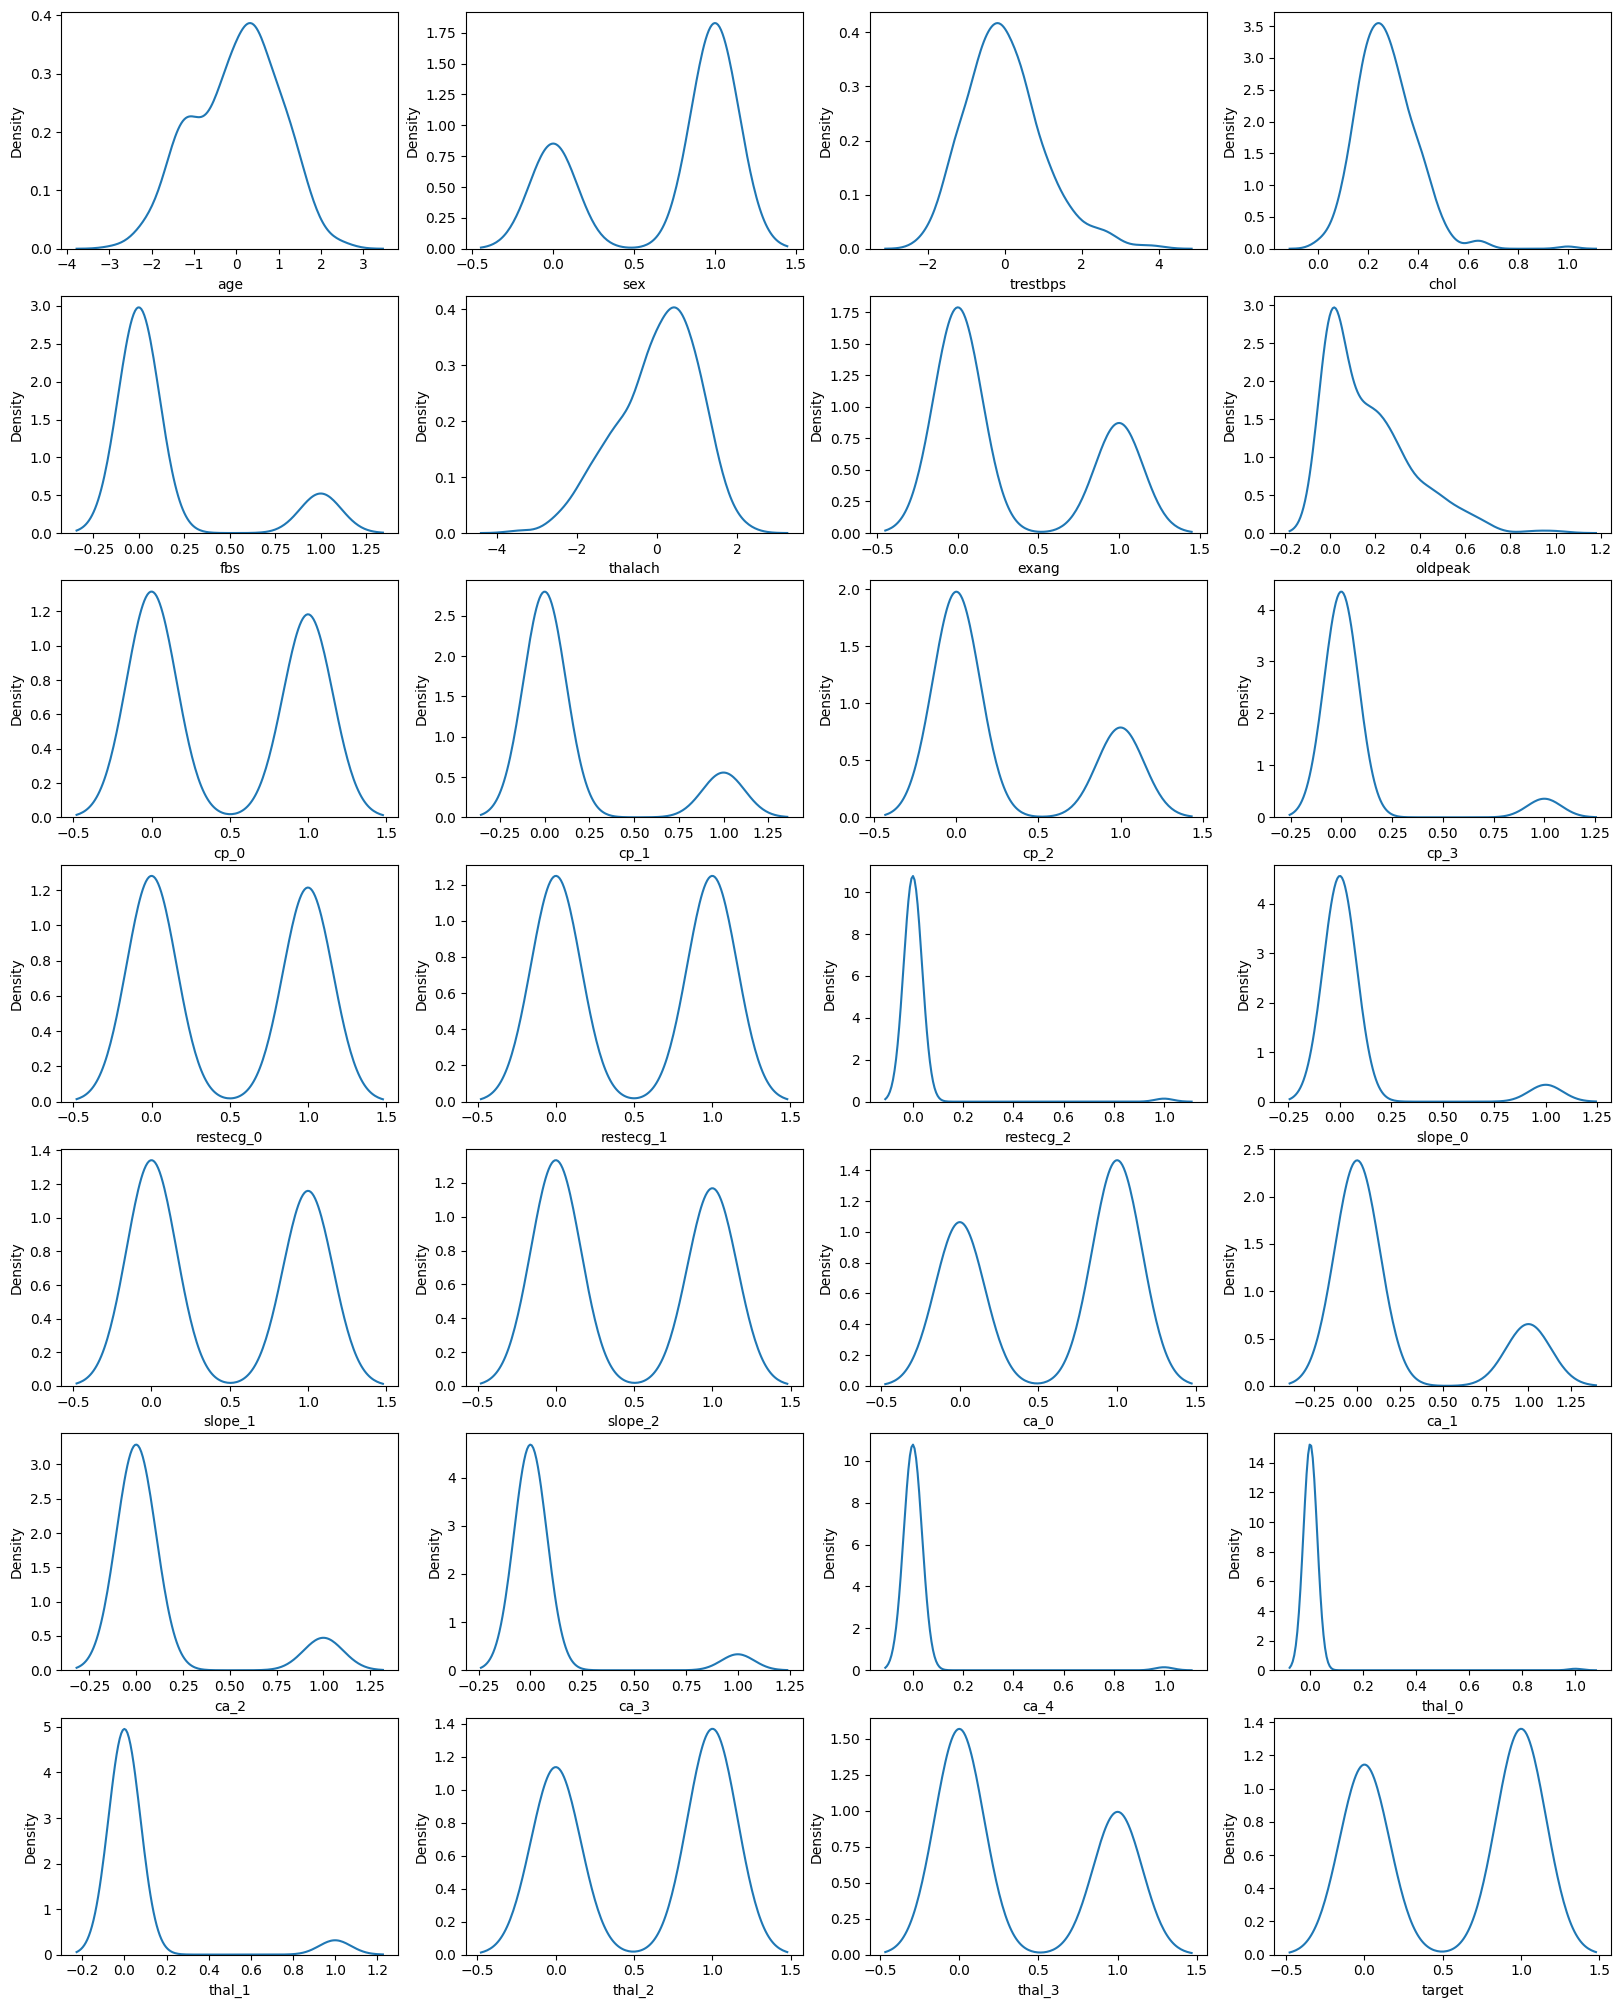

In [18]:
plot_kde(df)

In [19]:
def plot_outlier(df):
   numeric_cols = df.select_dtypes(include='number')
   plt.figure(figsize=(20,40))
   
   for i, col in enumerate(numeric_cols):
      plt.subplot(11,4, i+ 1)
      sns.boxplot(df[col])

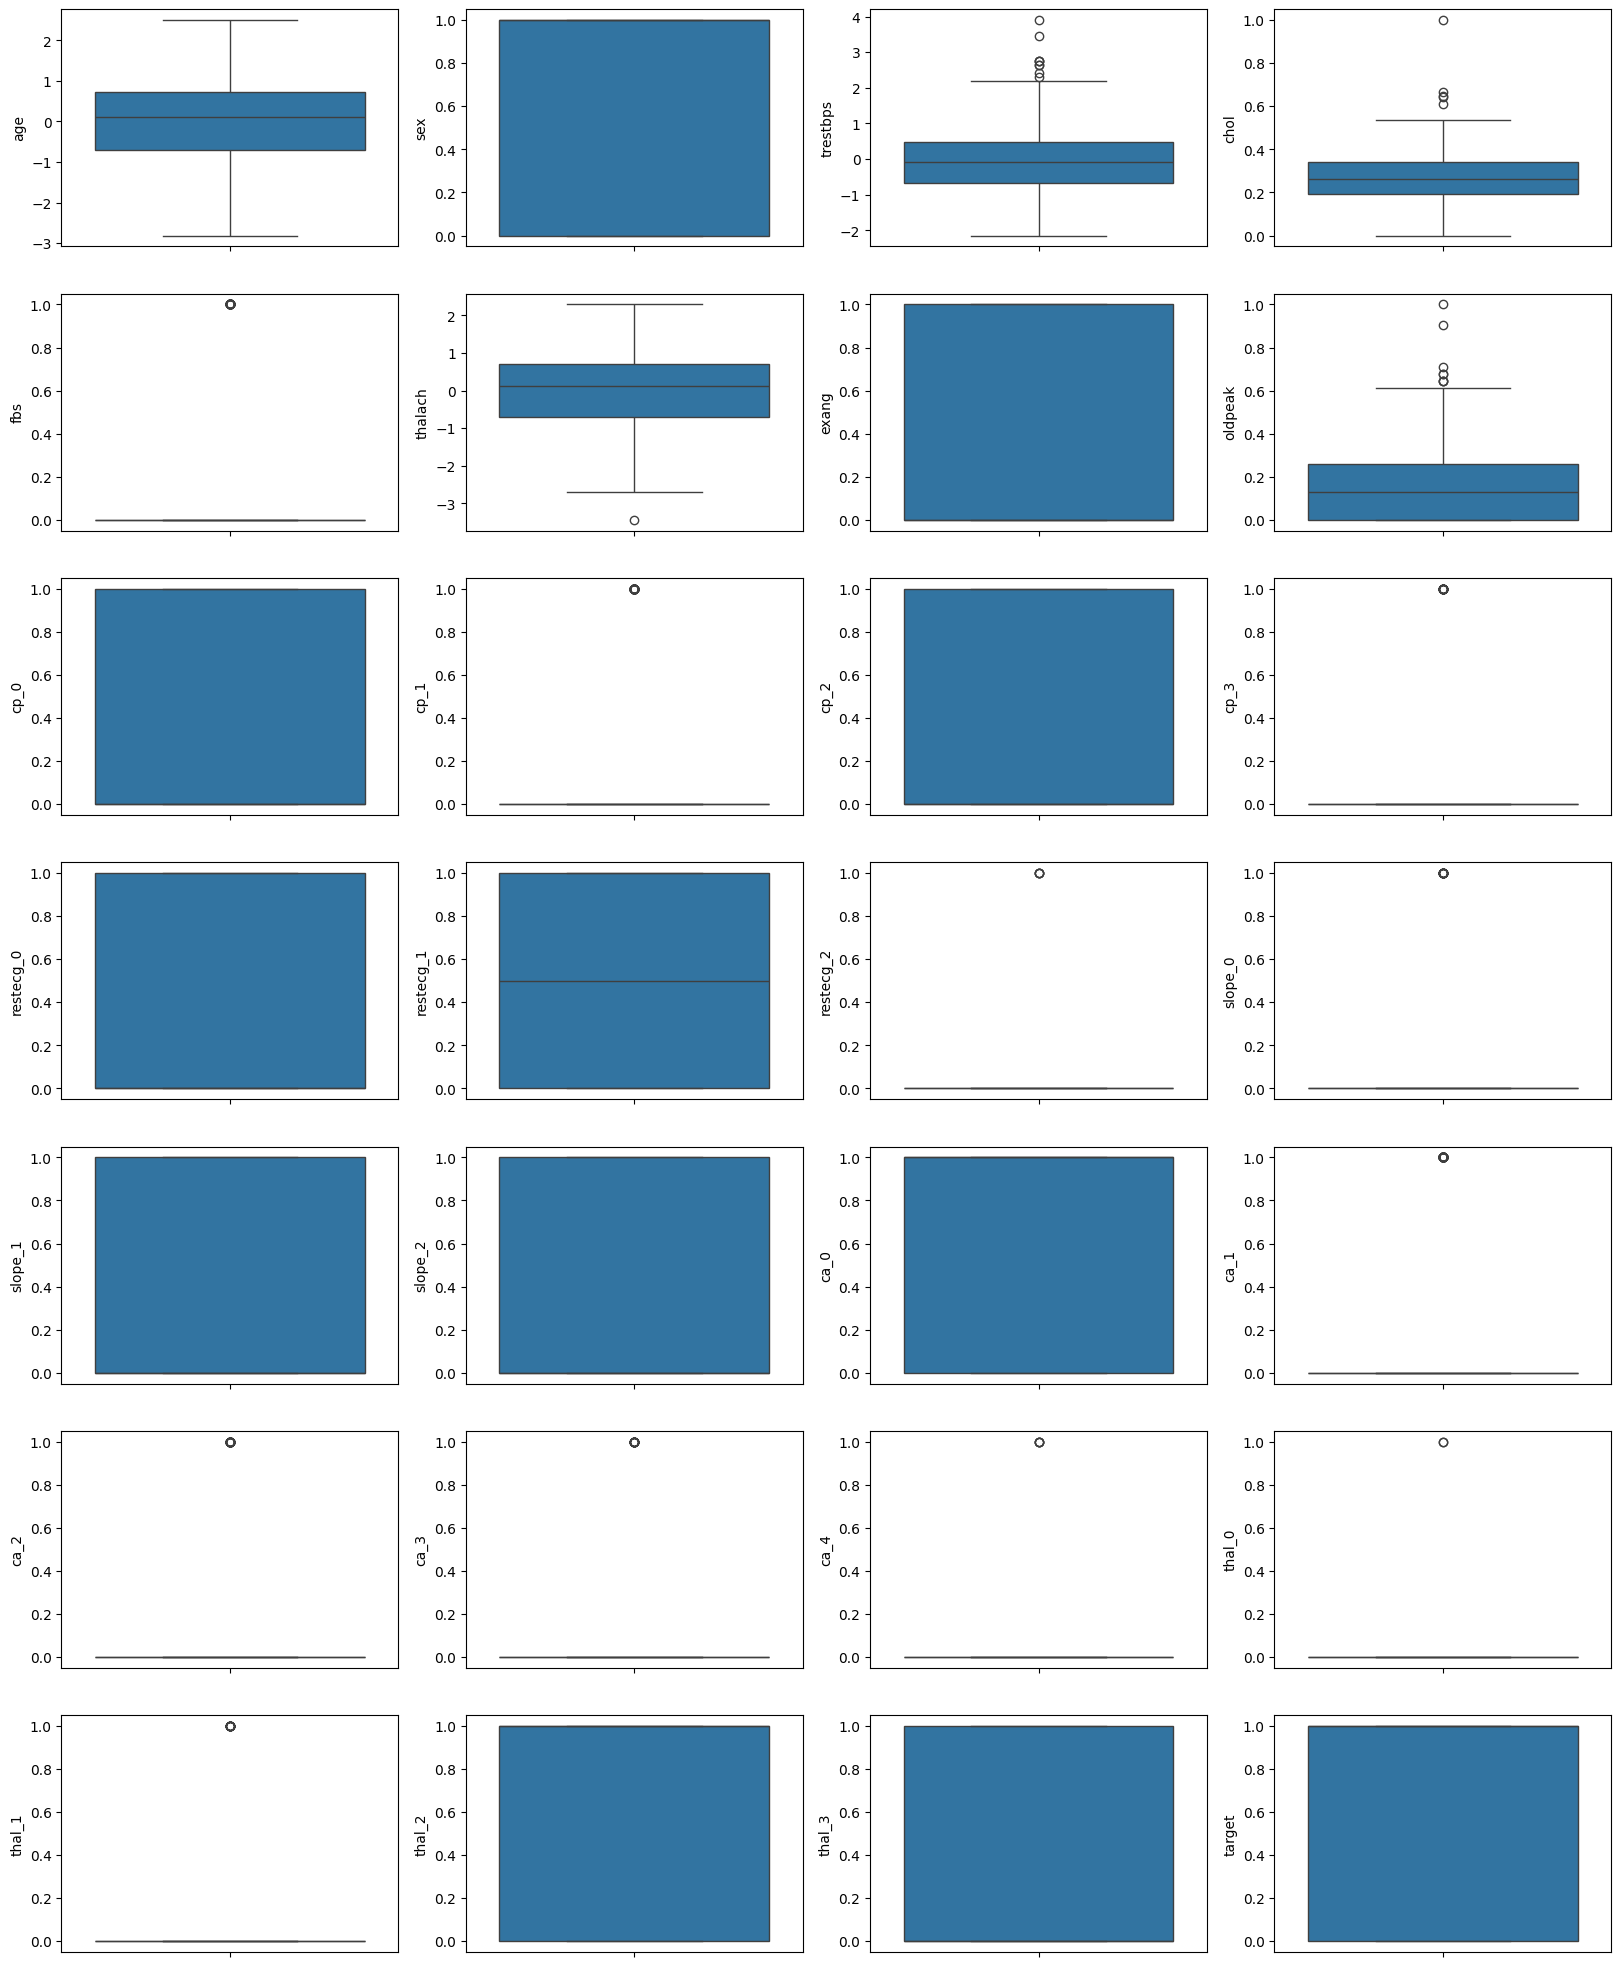

In [20]:
plot_outlier(df)

In [7]:
X = df.drop(columns='target')
y = df['target']

In [8]:
from sklearn.model_selection import train_test_split 


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score :  0.7868852459016393
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.75      0.83      0.79        29

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

